In [7]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
# --- 1. Blur (Sharpness) Analysis using Laplacian Variance ---
dataset_path = "../dataset"
blur_data = []

# Threshold for blurriness (Lower than this value indicates a blurry image)
# 100 is a common heuristic, but can be adjusted based on your dataset results.
blur_threshold = 25.0

if os.path.exists(dataset_path):
    print("Starting blur analysis...")
    for class_name in sorted(os.listdir(dataset_path)):
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            for f in os.listdir(class_dir):
                if f.lower().endswith(".jpg"):
                    file_path = os.path.join(class_dir, f)
                    try:
                        # Read image in grayscale using OpenCV
                        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                        if img is not None:
                            # Calculate Laplacian variance (sharpness score)
                            sharpness_score = cv2.Laplacian(img, cv2.CV_64F).var()
                            blur_data.append({
                                "Class": class_name,
                                "File_Path": file_path,
                                "Blur_Score": sharpness_score
                            })
                        else:
                            print(f"Could not read image: {file_path}")
                    except Exception as e:
                        print(f"Error processing file {file_path}: {e}")

    df_blur = pd.DataFrame(blur_data)
    print(f"Total scanned images for blur analysis: {len(df_blur)}")
else:
    print(f"Error: {dataset_path} does not exist")

Starting blur analysis...
Total scanned images for blur analysis: 119338


In [8]:
# --- 2. Analyze and Filter Blurry Images ---
if 'df_blur' in locals() and not df_blur.empty:
    print("\n--- Blur Score Statistics ---")
    print(df_blur["Blur_Score"].describe())

    # Filter blurry images below the threshold
    blurry_images = df_blur[df_blur["Blur_Score"] < blur_threshold]
    print(f"\nNumber of blurry images (score < {blur_threshold}): {len(blurry_images)}")

    if not blurry_images.empty:
        print("\n--- Sample Blurry Images (Lowest Scores) ---")
        display(blurry_images.sort_values(by="Blur_Score").head(10))

    # Report summary
    print("\n" + "="*45)
    print("BLUR ANALYSIS REPORT")
    print("="*45)
    print(f"Total Images Analyzed    : {len(df_blur)}")
    print(f"Blurry Images Count      : {len(blurry_images)}")
    print(f"Percentage of Blurry Imgs: {(len(blurry_images) / len(df_blur)) * 100:.2f}%")
    print("="*45)


--- Blur Score Statistics ---
count    119338.000000
mean        192.733076
std         263.762582
min           4.823860
25%          66.596212
50%         114.012964
75%         188.078942
max        1842.188840
Name: Blur_Score, dtype: float64

Number of blurry images (score < 25.0): 3907

--- Sample Blurry Images (Lowest Scores) ---


,Class,File_Path,Blur_Score
11332,C,../dataset/C/C_0_9439.jpg,4.823860
13476,C,../dataset/C/C_0_1836.jpg,5.186203
10821,C,../dataset/C/C_0_228.jpg,5.509896
102713,Y,../dataset/Y/Y_0_7354.jpg,6.417590
13579,C,../dataset/C/C_0_7400.jpg,6.781800
32684,G,../dataset/G/G_0_5904.jpg,6.876405
11459,C,../dataset/C/C_0_6938.jpg,7.021903
13181,C,../dataset/C/C_0_3920.jpg,7.128823
35316,H,../dataset/H/H_0_9115.jpg,7.145410
11611,C,../dataset/C/C_0_5185.jpg,7.246680



BLUR ANALYSIS REPORT
Total Images Analyzed    : 119338
Blurry Images Count      : 3907
Percentage of Blurry Imgs: 3.27%


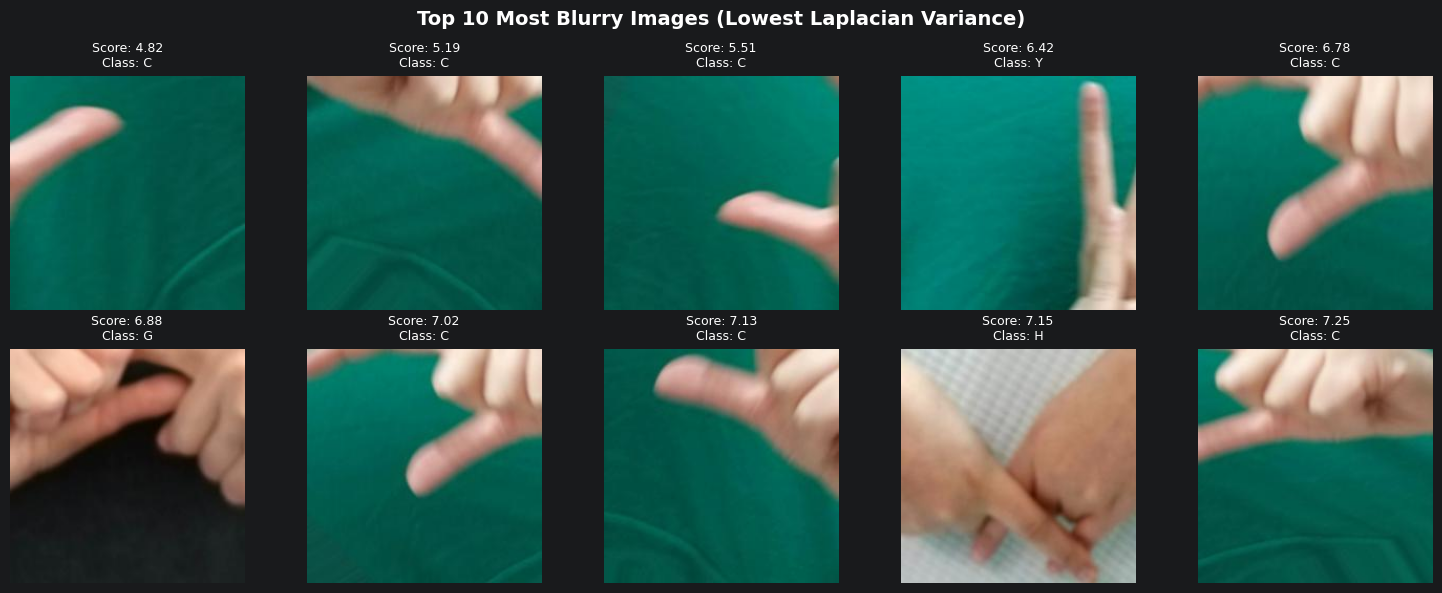

In [9]:
# --- Visualize the Most Blurry Images ---
if 'df_blur' in locals() and not df_blur.empty:
    # Number of images to display
    num_to_show = 10

    # Sort by Blur_Score ascending (lowest scores = most blurry)
    most_blurry = df_blur.sort_values(by="Blur_Score", ascending=True).head(num_to_show)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for idx, row in enumerate(most_blurry.itertuples()):
        ax = axes[idx]
        try:
            img = Image.open(row.File_Path)
            ax.imshow(img)
            ax.set_title(f"Score: {row.Blur_Score:.2f}\nClass: {row.Class}", fontsize=9)
            ax.axis("off")
        except Exception as e:
            ax.text(0.5, 0.5, "Error Loading", ha='center', va='center')
            ax.axis("off")

    plt.suptitle(f"Top {num_to_show} Most Blurry Images (Lowest Laplacian Variance)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df_blur' not found or empty. Run the blur analysis first.")